# Titanic - Machine Learning from Disaster

| Variable  | Definition                                   | Key                                      |
|-----------|----------------------------------------------|------------------------------------------|
| survival  | Survival                                     | 0 = No, 1 = Yes                          |
| pclass    | Ticket class                                 | 1 = 1st, 2 = 2nd, 3 = 3rd                |
| sex       | Sex                                          |                                          |
| age       | Age in years                                 |                                          |
| sibsp     | # of siblings / spouses aboard the Titanic   |                                          |
| parch     | # of parents / children aboard the Titanic   |                                          |
| ticket    | Ticket number                                |                                          |
| fare      | Passenger fare                               |                                          |
| cabin     | Cabin number                                 |                                          |
| embarked  | Port of Embarkation                          | C = Cherbourg, Q = Queenstown, S = Southampton |

---
## Import Libraries

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

---
## Read Files

In [2]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

---
## Explore the data

In [3]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
count_cabin = df_train['Cabin'].isnull().sum()
print(count_cabin, " null values")

687  null values


Based on this information this already gives us an idea of what might be interesting and what seems likely to be unnecessary. 

Things that might be unnecessary: 
- PassengerID,
- Cabin (too many null values, drop it)

This that might be interesting to keep: 
- Survived 
- Pclass (people with higher title have higher chance of survival?)
- Age

In [5]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


Age ==> Min age is a baby and the max age is 80 years old

Pclass ==> common class was the second class

In [6]:
# A summary of the categorical (text) columns
df_train.describe(include='O').T

C:\Users\fifif\AppData\Local\Temp\ipykernel_16108\3862125620.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_train.describe(include='O').T


,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


Note: Ticket has 681 unique values so does this mean that there are double in the tickets? 

Cabin can make sense because multiple people can be assigned to the same cabin


In [7]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

There are missing values in age , cabin and embarked

Cabin number has the higest amount of missing values

This can be interesting if we want to remove certain columns or change them 

In [9]:
print(len(df_train))

891


---
###  Classes Likely to survive

- Ticket class : this will impact your likelyhood of survival. If you have a higher classs you might be closer to the exit
- Sex: This will def have an impact as Women and children and elderly are known to have a priority when it comes to disasters
- Age: Same things age does impact survivalhood children and elderly will be prioritised 

In [10]:
#Look if women actualy had a higher survival rate than men
(df_train.groupby('Sex')['Survived'].mean()*100).map("{:.2f}%".format)


Sex
female    74.20%
male      18.89%
Name: Survived, dtype: str

Women had a higher percentage of survival with a 74% whereas men its as low as 19%.

In [11]:
#Look if class actually had an impact on survival
(df_train.groupby('Pclass')['Survived'].mean()*100).map("{:2f}%".format)

Pclass
1    62.962963%
2    47.282609%
3    24.236253%
Name: Survived, dtype: str

Also confirms the hypothesis that the higher classes did have a higher likelyhood of surviving , the third class survival was to be only 24%

In [12]:
#Look if age had an impact on the survival rates.
bins = int((df_train['Age'].max() - df_train['Age'].min()) / 5)
print(round(bins, 3))

15


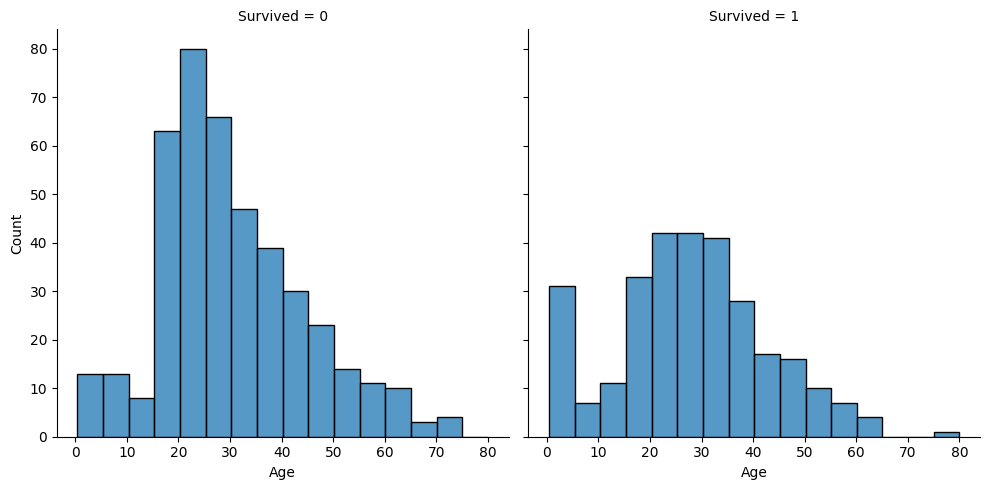

In [13]:
sns.displot(data=df_train, x='Age', col='Survived', bins=16)

Note: that people between 20 and 30 had the highest rates of not surviving the disaster

---

Look at the people who survived

In [14]:
df_train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [15]:
survival_rate = df_train['Survived'].value_counts(normalize=True)
print((survival_rate * 100), "%")


Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64 %


Look at the balance between those who have survived and those who didn't
We see that 61% did not survive whereas 38% did survive the disaster

Within those people look at the title they have as this also impact. We already know that class has an impact but if we search further we can check if the title of a person also influenced or not?

Look if the groupsize actually matter in surving? 

To do this it's best to combine them to like at family size in general. 
By combining the total family size, which is what actually matters for survival. And we also add  one to count for the passenger itself

In [16]:
#combine both siblings and spouses and childeren
df_train['Family-size'] = df_train['SibSp'] + df_train['Parch'] + 1
df_test['Family-size'] = df_test['SibSp'] + df_test['Parch'] + 1


In [17]:
df_train.groupby('Family-size')['Survived'].mean()*100

Family-size
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

what we can see is that smaller/ midsize family have a higher change of survival so with a max of 4 members anything above that had a lower chance of surviving

In [18]:
df_train.groupby('SibSp')['Survived'].mean()*100

SibSp
0    34.539474
1    53.588517
2    46.428571
3    25.000000
4    16.666667
5     0.000000
8     0.000000
Name: Survived, dtype: float64

Map to family to its size. 

In [ ]:
df_train.groupby('Ticket')['Survived'].mean()*100

Ticket
110152         100.000000
110413          66.666667
110465           0.000000
110564         100.000000
110813         100.000000
                  ...    
W./C. 6608       0.000000
W./C. 6609       0.000000
W.E.P. 5734      0.000000
W/C 14208        0.000000
WE/P 5735       50.000000
Name: Survived, Length: 681, dtype: float64

Data Cleaning: 
Based on the findings the data needs some cleaning some things will be dropped other will be filled
- Cabin --> drop because it has a lot of missing values
- Age --> fill with the median 
- Embarked --> fill with mode only 2 are missing
- PassengerId, Name, Ticket --> drop (not predictive)

In [ ]:
def clean_data(df):
    df = df.copy()

    #Drop columns with too many missing values or no predictive value
    df.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'], inplace=True)
    #inplace=True -->change the original df directly instead of creating a new one

    #Fill missing Age with median
    df['Age'].fillna(df['Age'].median(), inplace=True)

    #Fill missing Embarked with mode (most frequent value)
    df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
    #mode gives the most frequent value , 0 takes the first value from that result
    # in case there are mutliple modes it will take the first one 

    #Fill missing Fare (only in test set) with median
    df['Fare'].fillna(df['Fare'].median(), inplace=True)

    return df
#return sends the cleaned df back out of the function
# inside the def all changes happen to a local variable without 
#the return df, those changes stay inside the function and cannot use them outside


In [ ]:
df_train_clean = clean_data(df_train)
df_test_clean = clean_data(df_test)

C:\Users\fifif\AppData\Local\Temp\ipykernel_16108\1660520447.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\fifif\AppData\Local\Temp\ipykernel_16108\1660520447.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignm

In [ ]:
#Quick check : should show 0 missing values for all columns
print("Train missing values: \n", df_train_clean.isnull().sum())
print("\nTest missing values: \n", df_test_clean.isnull().sum())

Train missing values: 
 Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         2
Family-size      0
dtype: int64

Test missing values: 
 Pclass          0
Sex             0
Age            86
SibSp           0
Parch           0
Fare            1
Embarked        0
Family-size     0
dtype: int64
